# 課題4 Detection: Faster R-CNN / SSD

この課題では、CNN による物体検出を pretrained model で動かします。

Faster R-CNN は two-stage detector です。まず物体らしい領域候補を作り、その候補ごとにカテゴリ分類と bounding box 補正を行います。SSD は single-stage detector です。候補領域生成を別段階に分けず、複数スケールの feature map からカテゴリと bounding box を直接予測します。

## 実験方針

- 学校の COCO 画像を使います。
- Faster R-CNN と SSD の pretrained model を使います。
- 同じ COCO 画像に対して2つの detector を実行し、検出結果を見比べます。
- score がしきい値以上の bounding box を画像上に描画して `out/` に保存します。

In [1]:
from pathlib import Path
import json
import os
import random
import numpy as np
import torch
from torchvision import models
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# JupyterHub上での課題フォルダ。結果画像とsummaryは課題4のout/に保存する。
BASE_DIR = Path('/export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2')
TASK_DIR = BASE_DIR / 'kadai4-detection_fasterrcnn_ssd'
OUT_DIR = TASK_DIR / 'out'
MODEL_DIR = TASK_DIR / 'model'

# 学校・研究室で共有されているCOCO画像とannotationを使う。
COCO_DIR = Path('/export/data/dataset/COCO')
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('COCO exists:', COCO_DIR.exists())

device: cuda
COCO exists: True


## COCO から検出しやすい画像を選ぶ

COCO annotation が使える場合、`person` が写っている画像と、`bus`が写っている画像を選びます。annotation が見つからない場合は画像ファイルから fallback で2枚選びます。

In [2]:
def find_annotation_file(coco_dir):
    candidates = [
        coco_dir / 'annotations' / 'instances_train2014.json',
        coco_dir / 'annotations' / 'instances_val2014.json',
        coco_dir / 'annotations.org' / 'instances_train2014.json',
        coco_dir / 'annotations.org' / 'instances_val2014.json',
    ]
    for path in candidates:
        if path.exists():
            return path
    return None

def image_path_from_file_name(coco_dir, file_name):
    for split in ['train2014', 'val2014', 'test2014']:
        path = coco_dir / split / file_name
        if path.exists():
            return path
    matches = list(coco_dir.glob(f'**/{file_name}'))
    if matches:
        return matches[0]
    raise FileNotFoundError(file_name)

def select_coco_images_by_category(coco_dir):
    ann_path = find_annotation_file(coco_dir)
    selected = []
    if ann_path is not None:
        print('annotation:', ann_path)
        data = json.loads(ann_path.read_text())
        cat_name_to_id = {c['name']: c['id'] for c in data['categories']}
        image_id_to_file = {img['id']: img['file_name'] for img in data['images']}

        def pick(label, category_names):
            cat_ids = {cat_name_to_id[name] for name in category_names if name in cat_name_to_id}
            for ann in data['annotations']:
                if ann['category_id'] in cat_ids and ann.get('area', 0) > 3000:
                    file_name = image_id_to_file[ann['image_id']]
                    return {'label': label, 'target_categories': list(category_names), 'path': image_path_from_file_name(coco_dir, file_name)}
            return None

        selected.append(pick('person_image', ['person']))
        selected.append(pick('vehicle_image', ['bus']))
        selected = [s for s in selected if s is not None]

    if len(selected) < 2:
        print('annotation based selection failed. fallback to image files.')
        paths = []
        for split in ['val2014', 'train2014']:
            root = coco_dir / split
            if root.exists():
                paths.extend(sorted(root.glob('*.jpg')))
        if len(paths) < 2:
            raise FileNotFoundError(f'COCO images were not found under {coco_dir}')
        selected = [
            {'label': 'person_image_fallback', 'target_categories': ['person'], 'path': paths[10]},
            {'label': 'vehicle_image_fallback', 'target_categories': ['bus'], 'path': paths[50]},
        ]
    return selected[:2]

selected_images = select_coco_images_by_category(COCO_DIR)
images = []
for item in selected_images:
    img = Image.open(item['path']).convert('RGB')
    images.append({**item, 'image': img})
    print(item['label'], item['target_categories'], item['path'])

annotation: /export/data/dataset/COCO/annotations/instances_train2014.json
person_image ['person'] /export/data/dataset/COCO/train2014/COCO_train2014_000000196842.jpg
vehicle_image ['bus'] /export/data/dataset/COCO/train2014/COCO_train2014_000000415455.jpg


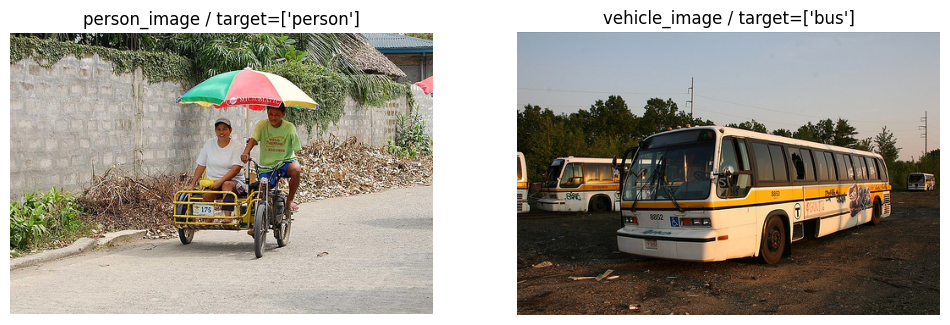

In [3]:
# 選ばれた2枚の画像を確認して保存する。
plt.figure(figsize=(12, 5))
for i, item in enumerate(images):
    plt.subplot(1, 2, i + 1)
    plt.imshow(item['image'])
    plt.axis('off')
    plt.title(f"{item['label']} / target={item['target_categories']}")
plt.savefig(OUT_DIR / 'selected_detection_images.png', dpi=160, bbox_inches='tight')
plt.show()

## 検出結果を描画する関数

Faster R-CNN と SSD はどちらも、`boxes`, `labels`, `scores` を返します。score がしきい値以上の box だけを描画します。

In [4]:
def draw_detections(img, pred, categories, score_thr=0.5, color='red'):
    out = img.copy()
    draw = ImageDraw.Draw(out)
    boxes = pred['boxes'].detach().cpu().numpy()
    labels = pred['labels'].detach().cpu().numpy()
    scores = pred['scores'].detach().cpu().numpy()
    kept = []

    for box, label_id, score in zip(boxes, labels, scores):
        if score < score_thr:
            continue
        name = categories[int(label_id)] if int(label_id) < len(categories) else str(int(label_id))
        x1, y1, x2, y2 = box.tolist()
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1, max(0, y1 - 12)), f'{name}: {score:.2f}', fill=color)
        kept.append({'label': name, 'score': float(score), 'box': [float(v) for v in box]})
    return out, kept

def run_detector(model, weights, pil_img):
    # torchvision detection modelはTensor画像のlistを入力に取る。
    x = weights.transforms()(TF.to_tensor(pil_img)).to(device)
    with torch.no_grad():
        pred = model([x])[0]
    return pred

## Faster R-CNN

Faster R-CNN は two-stage detector です。Region Proposal Network で物体候補領域を作り、その候補領域を分類して bounding box を補正します。一般に高精度ですが、SSD のような single-stage detector より重くなりやすいです。

In [5]:
# ImageNet/COCOで事前学習済みのFaster R-CNNを読み込む。
frcnn_weights = models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
frcnn_categories = frcnn_weights.meta['categories']
frcnn = models.detection.fasterrcnn_resnet50_fpn(weights=frcnn_weights).to(device).eval()

frcnn_outputs = []
for item in images:
    pred = run_detector(frcnn, frcnn_weights, item['image'])
    drawn, kept = draw_detections(item['image'], pred, frcnn_categories, score_thr=0.5, color='red')
    frcnn_outputs.append({**item, 'pred': pred, 'drawn': drawn, 'kept': kept})
    print(item['label'], 'detections:', len(kept), kept[:5])

/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


person_image detections: 8 [{'label': 'person', 'score': 0.9982849955558777, 'box': [203.19691467285156, 101.63133239746094, 279.0531921386719, 211.43927001953125]}, {'label': 'person', 'score': 0.9978379607200623, 'box': [274.2962951660156, 83.50541687011719, 346.3003845214844, 222.7520294189453]}, {'label': 'umbrella', 'score': 0.9862068891525269, 'box': [196.40628051757812, 41.55953598022461, 367.0834045410156, 110.18285369873047]}, {'label': 'bicycle', 'score': 0.9494437575340271, 'box': [279.76898193359375, 147.14437866210938, 336.4465637207031, 264.35137939453125]}, {'label': 'umbrella', 'score': 0.8639475107192993, 'box': [477.48779296875, 50.54330062866211, 500.0, 76.39672088623047]}]
vehicle_image detections: 5 [{'label': 'bus', 'score': 0.99834144115448, 'box': [115.49362182617188, 110.20879364013672, 437.6854553222656, 275.4673156738281]}, {'label': 'bus', 'score': 0.9912051558494568, 'box': [460.7377014160156, 167.01019287109375, 494.8757629394531, 189.1877899169922]}, {'la

## SSD

SSD は single-stage detector です。あらかじめ用意した default box に対して、カテゴリと bounding box 補正を直接予測します。Region proposal を別に作らないため高速にしやすい設計です。

In [6]:
# COCOで事前学習済みのSSDを読み込む。
ssd_weights = models.detection.SSD300_VGG16_Weights.DEFAULT
ssd_categories = ssd_weights.meta['categories']
ssd = models.detection.ssd300_vgg16(weights=ssd_weights).to(device).eval()

ssd_outputs = []
for item in images:
    pred = run_detector(ssd, ssd_weights, item['image'])
    drawn, kept = draw_detections(item['image'], pred, ssd_categories, score_thr=0.5, color='blue')
    ssd_outputs.append({**item, 'pred': pred, 'drawn': drawn, 'kept': kept})
    print(item['label'], 'detections:', len(kept), kept[:5])

person_image detections: 3 [{'label': 'umbrella', 'score': 0.7612024545669556, 'box': [193.6833953857422, 41.13631820678711, 363.84405517578125, 132.36512756347656]}, {'label': 'person', 'score': 0.7476861476898193, 'box': [265.2246398925781, 86.35826873779297, 345.94805908203125, 243.41357421875]}, {'label': 'person', 'score': 0.5054959654808044, 'box': [211.4161376953125, 104.58489990234375, 280.0662536621094, 192.96275329589844]}]
vehicle_image detections: 2 [{'label': 'bus', 'score': 0.9989489912986755, 'box': [101.22513580322266, 113.91361236572266, 443.2212829589844, 273.82122802734375]}, {'label': 'truck', 'score': 0.6407142281532288, 'box': [17.574207305908203, 146.45993041992188, 124.85134887695312, 216.11538696289062]}]


## Faster R-CNN と SSD の結果を比較

同じ画像に対して、左に Faster R-CNN、右に SSD の検出結果を表示します。赤が Faster R-CNN、青が SSD です。

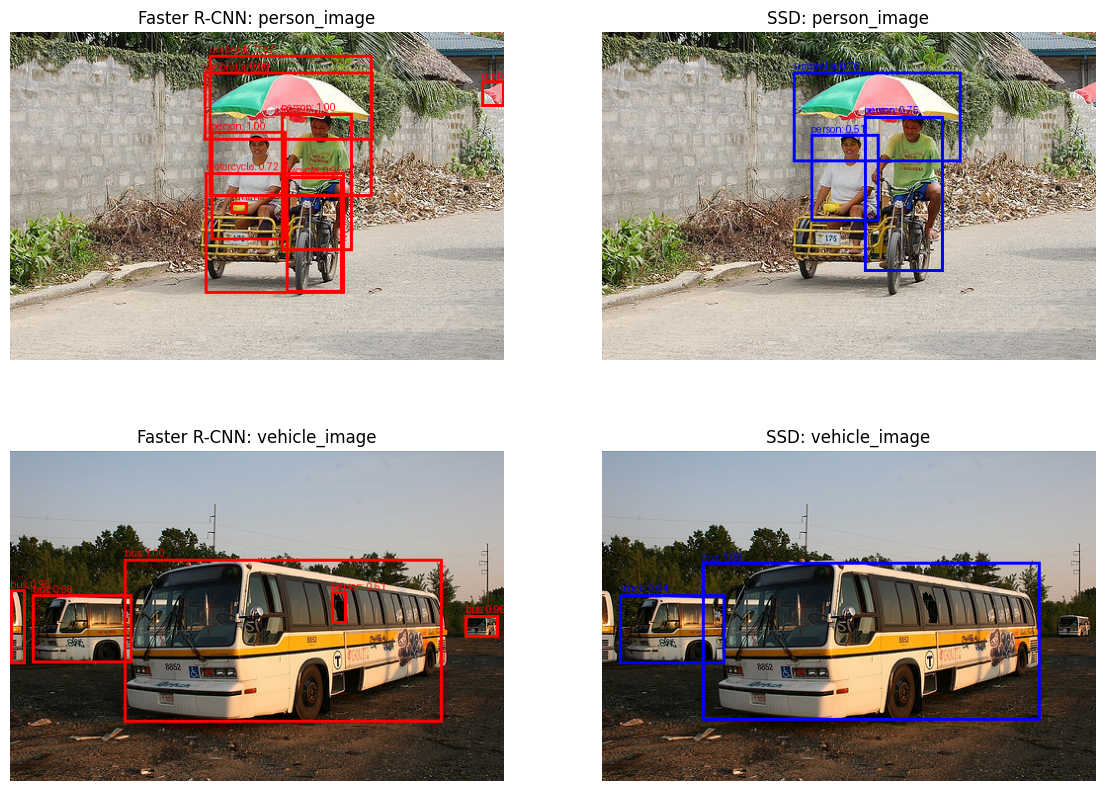

In [7]:
plt.figure(figsize=(14, 10))
for i in range(len(images)):
    plt.subplot(len(images), 2, 2 * i + 1)
    plt.imshow(frcnn_outputs[i]['drawn'])
    plt.axis('off')
    plt.title(f"Faster R-CNN: {images[i]['label']}")

    plt.subplot(len(images), 2, 2 * i + 2)
    plt.imshow(ssd_outputs[i]['drawn'])
    plt.axis('off')
    plt.title(f"SSD: {images[i]['label']}")

plt.savefig(OUT_DIR / 'detection_fasterrcnn_vs_ssd.png', dpi=160, bbox_inches='tight')
plt.show()

In [8]:
# レポートに使いやすいよう、検出結果のsummaryをJSONにも保存する。
summary = []
for i, item in enumerate(images):
    summary.append({
        'image_label': item['label'],
        'image_path': str(item['path']),
        'target_categories': item['target_categories'],
        'faster_rcnn_detections': frcnn_outputs[i]['kept'],
        'ssd_detections': ssd_outputs[i]['kept'],
    })

summary_path = OUT_DIR / 'detection_summary.json'
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved:', summary_path)

saved: /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/kadai4-detection_fasterrcnn_ssd/out/detection_summary.json


## まとめ

Faster R-CNN は候補領域を作ってから分類する two-stage detector であり、精度重視の設計です。SSD は候補領域生成を分けずに直接予測する single-stage detector であり、高速化しやすい設計です。pretrained model を使うことで、学習なしで COCO 画像中の person, bus, などを検出できることを確認しました。